# Tesseract

In [1]:
import cv2
import imutils
import numpy as np
from matplotlib import pyplot as plt
import pytesseract 

In [2]:
pytesseract.pytesseract.tesseract_cmd = r'C:\tesseract\tesseract.exe'

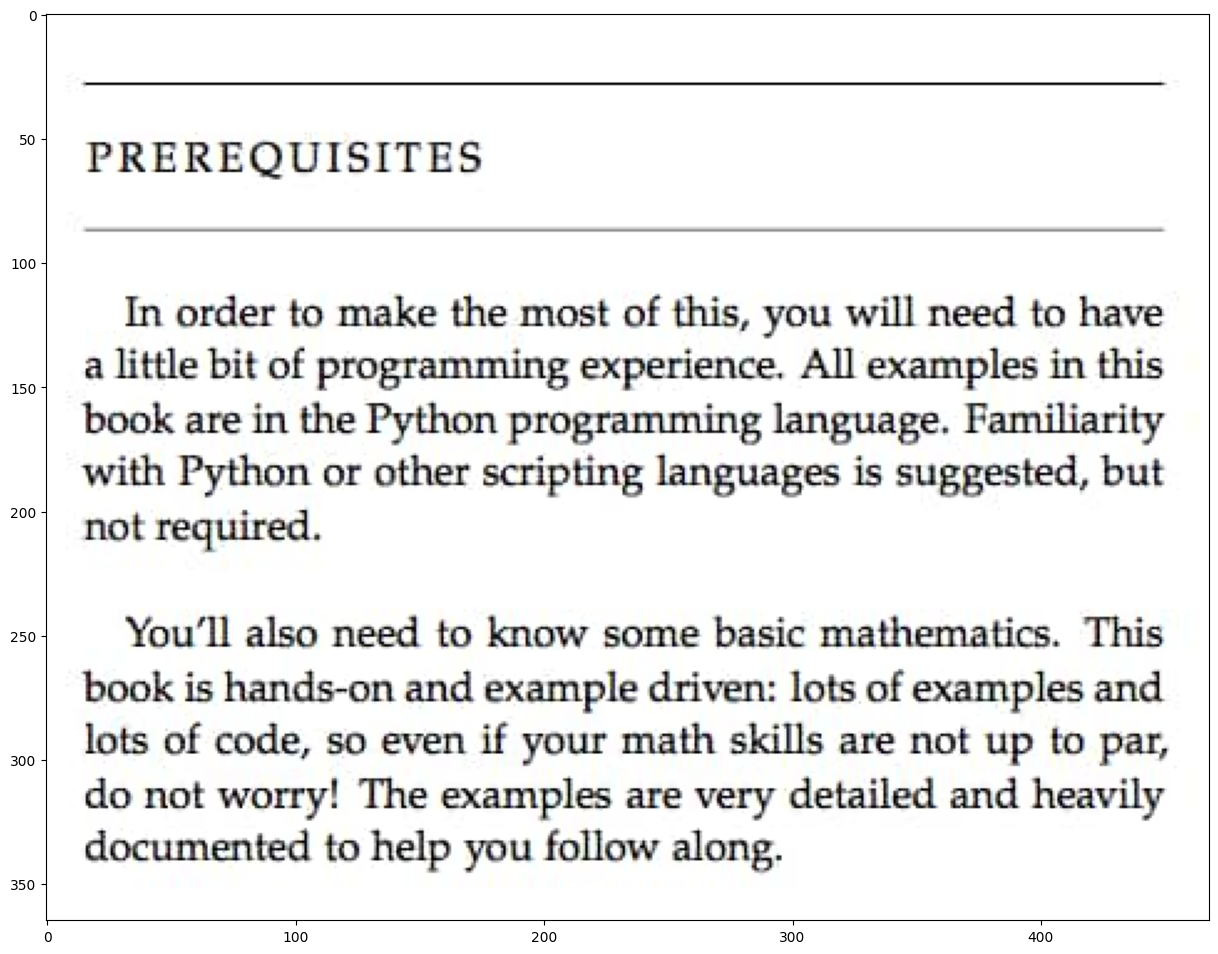

In [3]:
image = cv2.imread("text.jpg")
I = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(I)
plt.show()

Рассмотрим еще один метод `image_to_pdf_or_hocr`

In [4]:
hocr = pytesseract.image_to_pdf_or_hocr(image, extension='hocr', lang='eng')

In [5]:
hocr

b'<?xml version="1.0" encoding="UTF-8"?>\n<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN"\n    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">\n<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en" lang="en">\n <head>\n  <title></title>\n  <meta http-equiv="Content-Type" content="text/html;charset=utf-8"/>\n  <meta name=\'ocr-system\' content=\'tesseract v5.5.0.20241111\' />\n  <meta name=\'ocr-capabilities\' content=\'ocr_page ocr_carea ocr_par ocr_line ocrx_word ocrp_dir ocrp_lang ocrp_wconf\'/>\n </head>\n <body>\n  <div class=\'ocr_page\' id=\'page_1\' title=\'image "C:\\Users\\AMFD03~1.DUL\\AppData\\Local\\Temp\\tess_uto7fb6m_input.PNG"; bbox 0 0 468 365; ppageno 0; scan_res 70 70\'>\n   <div class=\'ocr_separator\' id=\'block_1_1\' title="bbox 15 27 450 30"></div>\n   <div class=\'ocr_carea\' id=\'block_1_2\' title="bbox 17 52 175 67">\n    <p class=\'ocr_par\' id=\'par_1_1\' lang=\'eng\' title="bbox 17 52 175 67">\n     <span class=\'ocr_line\' id=\'

In [6]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(hocr, 'html.parser') # Вспомните, для чего используется эта библиотека?

In [7]:
soup

<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">

<html lang="en" xml:lang="en" xmlns="http://www.w3.org/1999/xhtml">
<head>
<title></title>
<meta content="text/html;charset=utf-8" http-equiv="Content-Type"/>
<meta content="tesseract v5.5.0.20241111" name="ocr-system"/>
<meta content="ocr_page ocr_carea ocr_par ocr_line ocrx_word ocrp_dir ocrp_lang ocrp_wconf" name="ocr-capabilities"/>
</head>
<body>
<div class="ocr_page" id="page_1" title='image "C:\Users\AMFD03~1.DUL\AppData\Local\Temp\tess_uto7fb6m_input.PNG"; bbox 0 0 468 365; ppageno 0; scan_res 70 70'>
<div class="ocr_separator" id="block_1_1" title="bbox 15 27 450 30"></div>
<div class="ocr_carea" id="block_1_2" title="bbox 17 52 175 67">
<p class="ocr_par" id="par_1_1" lang="eng" title="bbox 17 52 175 67">
<span class="ocr_line" id="line_1_1" title="bbox 17 52 175 67; baseline 0 -3; x_size 16; x_descenders 4; x_as

Здесь мы наблюдаем следующие теги: `ocr_carea`, `ocr_line`, `ocrx_word`

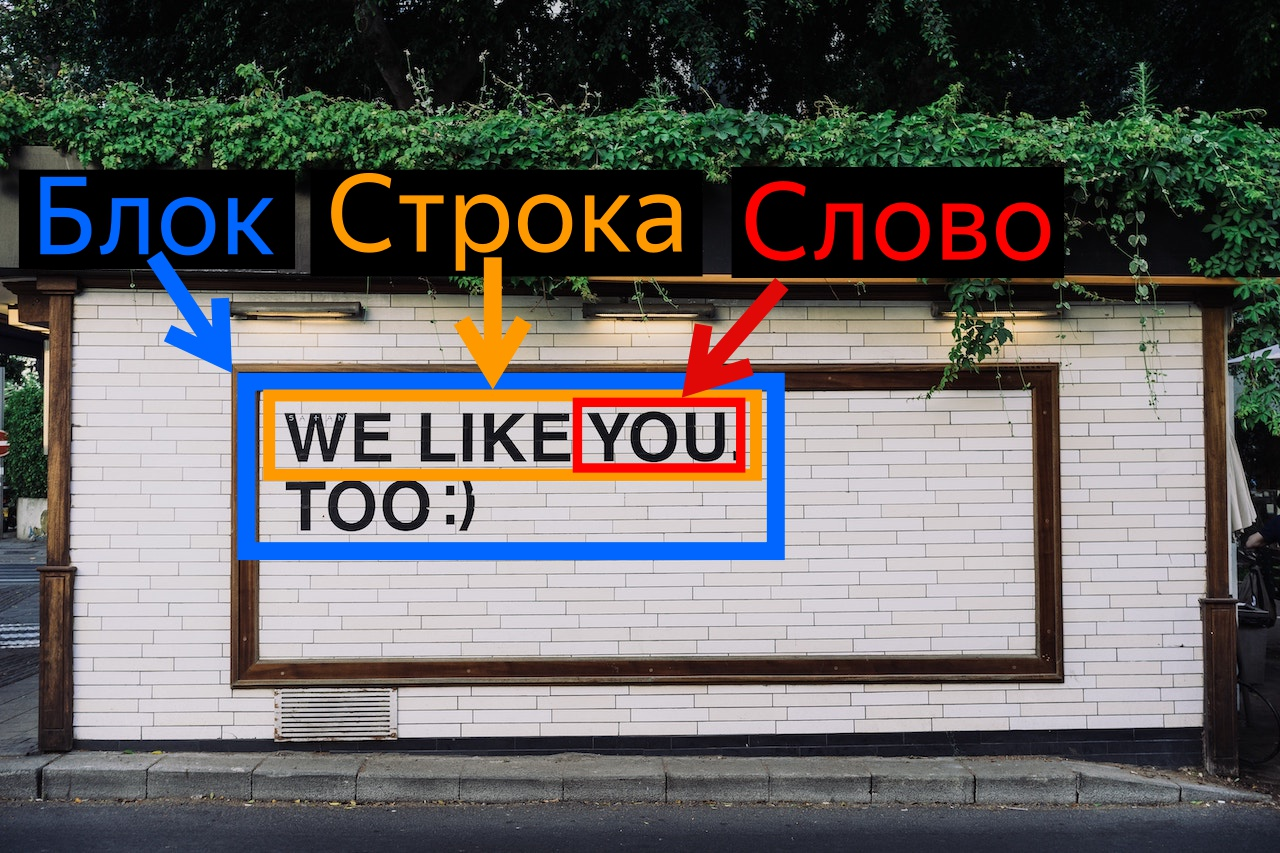

In [8]:
import re

Создадим регулярные выражения для поиска нужных блоков

In [13]:
COORDINATES_PATTERN = re.compile(r"bbox\s(-?[0-9]+)\s(-?[0-9]+)\s(-?[0-9]+)\s(-?[0-9]+)")
CONF_PATTERN = re.compile(r"x_wconf\s(-?[0-9]+)")
WORD_PATTERN = re.compile(r">(.*?)</span>")

In [10]:
# создадим список слов и будем запоминать номер строки
word_list = []
s_n = 0

# построчные области
for s in soup.find_all(class_='ocr_line'):

    text = s.text.split()
    if len(text) > 0:

        # пословные области
        for s_word in s.find_all(class_='ocrx_word'):
            
            # слово, его координаты и мера уверенности
            match_word = WORD_PATTERN.search(str(s_word))
            match_coord = COORDINATES_PATTERN.search(str(s_word))
            match_conf = CONF_PATTERN.search(str(s_word))

            word = []
            match_word = match_word.group().strip()
            word.append(match_word[1:len(match_word) - 7])
            word.append([int(match_coord.group(1)),
                         int(match_coord.group(2)),
                         int(match_coord.group(3)),
                         int(match_coord.group(4))])
            word.append(int(match_conf.group(1)))
            word.append(s_n)

            word_list.append(word)

        s_n += 1

In [11]:
word_list

[['PREREQUISITES', [17, 52, 175, 67], 96, 0],
 ['In', [32, 114, 47, 126], 95, 1],
 ['order', [53, 114, 92, 126], 95, 1],
 ['to', [98, 115, 111, 126], 96, 1],
 ['make', [118, 114, 157, 126], 96, 1],
 ['the', [163, 114, 185, 126], 96, 1],
 ['most', [191, 116, 226, 126], 96, 1],
 ['of', [233, 113, 247, 126], 96, 1],
 ['this,', [252, 113, 283, 128], 93, 1],
 ['you', [289, 118, 316, 131], 93, 1],
 ['will', [322, 113, 350, 126], 96, 1],
 ['need', [355, 114, 390, 126], 92, 1],
 ['to', [396, 115, 410, 126], 96, 1],
 ['have', [416, 114, 449, 126], 96, 1],
 ['alittle', [16, 135, 61, 147], 82, 2],
 ['bit', [65, 135, 85, 147], 95, 2],
 ['of', [90, 135, 104, 147], 96, 2],
 ['programming', [109, 135, 210, 152], 95, 2],
 ['experience.', [215, 135, 296, 152], 96, 2],
 ['All', [304, 135, 325, 147], 96, 2],
 ['examples', [331, 135, 399, 152], 94, 2],
 ['in', [404, 135, 418, 147], 96, 2],
 ['this', [424, 135, 449, 147], 96, 2],
 ['book', [15, 157, 52, 169], 96, 3],
 ['are', [56, 161, 79, 169], 96, 3],
 [

Средняя мера уверенности всех слов

In [12]:
np.mean([i[2] for i in word_list])

np.float64(95.14285714285714)

## [Задание]

Можете использовать любое изображение с текстом.

1. Нарисуйте ограничивающие прямоугольники для всех слов
2. Сравните результат с OpenCV. Сделайте выводы
3. Попробуйте сохранить изображение отдельного слова и распознать его повторно. Какие результаты?